In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train_path = "../artifacts/train.csv"

train_df = pd.read_csv(train_path)

print("Shape:", train_df.shape)
print("Unique orders:", train_df["order_id"].nunique())
print("Missing labels:", train_df["late"].isna().sum())

Shape: (77180, 23)
Unique orders: 77180
Missing labels: 0


In [3]:
print("=== BASIC DATASET INFORMATION ===")

print("Rows:", len(train_df))
print("Columns:", len(train_df.columns))

print("\nUnique orders:")
print(train_df["order_id"].nunique())

print("\nDuplicate rows:")
print(train_df.duplicated().sum())

print("\nDuplicate order IDs:")
print(train_df["order_id"].duplicated().sum())

=== BASIC DATASET INFORMATION ===
Rows: 77180
Columns: 23

Unique orders:
77180

Duplicate rows:
0

Duplicate order IDs:
0


In [4]:
print("=== FIRST 5 ROWS ===")

display(train_df.head())

=== FIRST 5 ROWS ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_count,total_items_price,...,payment_count,total_payment_value,payment_types,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score,late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,3.0,134.97,...,NaN,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,1.0,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,1.0,29.90,...,1.0,45.46,1.0,1.0,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,4.0,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,1.0,21.90,...,1.0,39.09,1.0,1.0,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,4.0,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,1.0,21.50,...,1.0,35.61,1.0,1.0,b8b8726af116a5cfb35b0315ecef9172,22770,rio de janeiro,RJ,1.0,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,1.0,36.49,...,1.0,53.73,1.0,1.0,61db744d2f835035a5625b59350c6b63,90040,porto alegre,RS,3.0,0


In [5]:
print("=== DATA TYPES ===")

train_df.info()
memory_mb = train_df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"\nMemory usage: {memory_mb:.2f} MB")

=== DATA TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77180 entries, 0 to 77179
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       77180 non-null  object 
 1   customer_id                    77180 non-null  object 
 2   order_status                   77180 non-null  object 
 3   order_purchase_timestamp       77180 non-null  object 
 4   order_approved_at              77166 non-null  object 
 5   order_delivered_carrier_date   77179 non-null  object 
 6   order_delivered_customer_date  77180 non-null  object 
 7   order_estimated_delivery_date  77180 non-null  object 
 8   item_count                     77180 non-null  float64
 9   total_items_price              77180 non-null  float64
 10  total_freight_value            77180 non-null  float64
 11  unique_products                77180 non-null  float64
 12  unique_sellers             

In [6]:
id_cols = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

categorical_cols = [
    "order_status",
    "payment_types",
    "customer_city",
    "customer_state"
]

numeric_cols = [
    "item_count",
    "total_items_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "max_installments",
    "customer_zip_code_prefix",
    "review_score"
]

print("ID columns:", id_cols)
print("Date columns:", date_cols)
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

ID columns: ['order_id', 'customer_id', 'customer_unique_id']
Date columns: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Categorical columns: ['order_status', 'payment_types', 'customer_city', 'customer_state']
Numeric columns: ['item_count', 'total_items_price', 'total_freight_value', 'unique_products', 'unique_sellers', 'payment_count', 'total_payment_value', 'max_installments', 'customer_zip_code_prefix', 'review_score']


In [7]:
missing_summary = pd.DataFrame({
    "dtype": train_df.dtypes,
    "missing": train_df.isna().sum(),
    "missing_pct": (
        train_df.isna().mean() * 100
    ).round(2),
    "unique": train_df.nunique(dropna=True)
})

missing_summary = (
    missing_summary
    .sort_values("missing", ascending=False)
)

print("=== MISSING VALUES ===")

display(
    missing_summary[
        missing_summary["missing"] > 0
    ]
)

=== MISSING VALUES ===


,dtype,missing,missing_pct,unique
review_score,float64,561,0.73,11
order_approved_at,object,14,0.02,71511
order_delivered_carrier_date,object,1,0.00,69164
total_payment_value,float64,1,0.00,23139
payment_types,float64,1,0.00,2
payment_count,float64,1,0.00,19
max_installments,float64,1,0.00,23


In [8]:
print("=== TARGET DISTRIBUTION ===")

target_counts = train_df["late"].value_counts().sort_index()

target_percentages = (
    train_df["late"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

display(target_summary)

=== TARGET DISTRIBUTION ===


,count,percentage
late,,
0,70374,91.18
1,6806,8.82


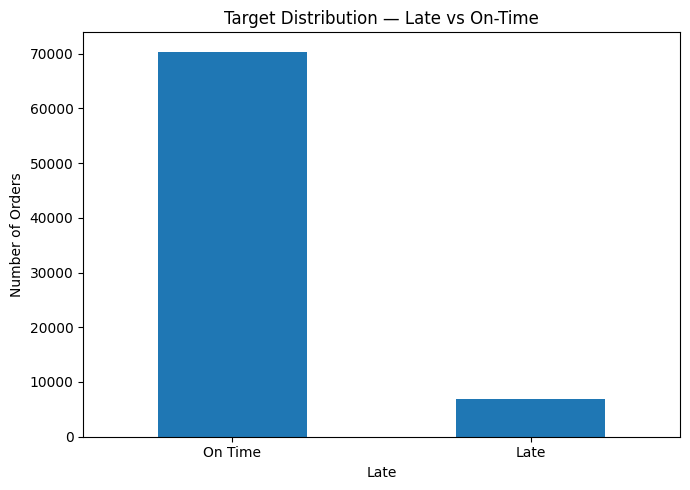

In [9]:
plt.figure(figsize=(7, 5))

target_counts.plot(
    kind="bar"
)

plt.title("Target Distribution — Late vs On-Time")
plt.xlabel("Late")
plt.ylabel("Number of Orders")
plt.xticks(
    ticks=[0, 1],
    labels=["On Time", "Late"],
    rotation=0
)

plt.tight_layout()

os.makedirs("../artifacts/eda_plots", exist_ok=True)

plt.savefig(
    "../artifacts/eda_plots/target_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [10]:
late_rate = train_df["late"].mean() * 100

print("=== CLASS IMBALANCE ===")

print(f"On-time orders: {(train_df['late'] == 0).sum():,}")
print(f"Late orders:    {(train_df['late'] == 1).sum():,}")
print(f"Late rate:      {late_rate:.2f}%")

=== CLASS IMBALANCE ===
On-time orders: 70,374
Late orders:    6,806
Late rate:      8.82%


In [11]:
numeric_features_for_eda = [
    col for col in numeric_cols
    if col != "late"
]

numeric_summary = train_df[
    numeric_features_for_eda
].describe().T

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
item_count,77180.0,1.144053,0.545313,1.00,1.00,1.00,1.00,21.00
total_items_price,77180.0,136.653030,206.033270,0.85,45.90,86.90,149.90,13440.00
total_freight_value,77180.0,22.276957,20.328222,0.00,13.81,16.79,23.70,1002.29
unique_products,77180.0,1.038326,0.224696,1.00,1.00,1.00,1.00,7.00
unique_sellers,77180.0,1.012853,0.118472,1.00,1.00,1.00,1.00,5.00
payment_count,77179.0,1.046645,0.390486,1.00,1.00,1.00,1.00,26.00
total_payment_value,77179.0,158.965030,215.345721,10.07,61.79,104.70,175.77,13664.08
max_installments,77179.0,2.955389,2.735731,0.00,1.00,2.00,4.00,24.00
customer_zip_code_prefix,77180.0,35717.254366,29887.241413,1003.00,11740.00,25585.00,60115.00,99980.00
review_score,76619.0,4.116957,1.308490,1.00,4.00,5.00,5.00,5.00


In [12]:
skewness = (
    train_df[numeric_features_for_eda]
    .skew()
    .sort_values(ascending=False)
)

skewness_df = pd.DataFrame({
    "skewness": skewness
})

print("=== NUMERICAL SKEWNESS ===")

display(skewness_df)

=== NUMERICAL SKEWNESS ===


,skewness
payment_count,21.986063
total_items_price,10.117273
unique_sellers,10.114979
total_payment_value,9.586453
total_freight_value,8.120029
item_count,7.836545
unique_products,7.700015
max_installments,1.590477
customer_zip_code_prefix,0.754505
review_score,-1.413259


In [13]:
numerical_ranges = pd.DataFrame({
    "min": train_df[numeric_features_for_eda].min(),
    "max": train_df[numeric_features_for_eda].max(),
    "mean": train_df[numeric_features_for_eda].mean(),
    "median": train_df[numeric_features_for_eda].median()
})

print("=== NUMERICAL RANGES ===")

display(numerical_ranges)

=== NUMERICAL RANGES ===


,min,max,mean,median
item_count,1.00,21.00,1.144053,1.00
total_items_price,0.85,13440.00,136.653030,86.90
total_freight_value,0.00,1002.29,22.276957,16.79
unique_products,1.00,7.00,1.038326,1.00
unique_sellers,1.00,5.00,1.012853,1.00
payment_count,1.00,26.00,1.046645,1.00
total_payment_value,10.07,13664.08,158.965030,104.70
max_installments,0.00,24.00,2.955389,2.00
customer_zip_code_prefix,1003.00,99980.00,35717.254366,25585.00
review_score,1.00,5.00,4.116957,5.00


In [14]:
print("=== NUMERICAL FEATURES BY TARGET ===")

for col in numeric_features_for_eda:

    stats = (
        train_df
        .groupby("late")[col]
        .agg(["count", "mean", "median"])
    )

    print("\n" + "=" * 60)
    print(col)
    display(stats)

=== NUMERICAL FEATURES BY TARGET ===

item_count


,count,mean,median
late,,,
0,70374,1.147043,1.0
1,6806,1.113135,1.0



total_items_price


,count,mean,median
late,,,
0,70374,135.454923,85.00
1,6806,149.041447,90.45



total_freight_value


...

,count,mean,median
late,,,
0,70374,2.941512,2.0
1,6805,3.098898,2.0



customer_zip_code_prefix


,count,mean,median
late,,,
0,70374,35324.443260,24358.0
1,6806,39778.918895,29164.0



review_score


,count,mean,median
late,,,
0,69959,4.275792,5.0
1,6660,2.448498,2.0


<Figure size 700x500 with 0 Axes>

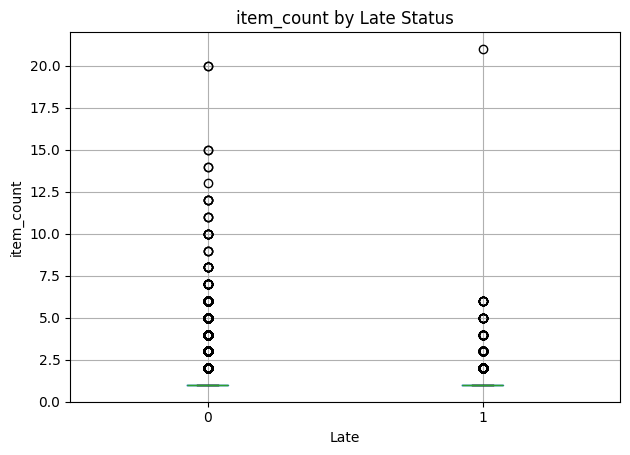

<Figure size 700x500 with 0 Axes>

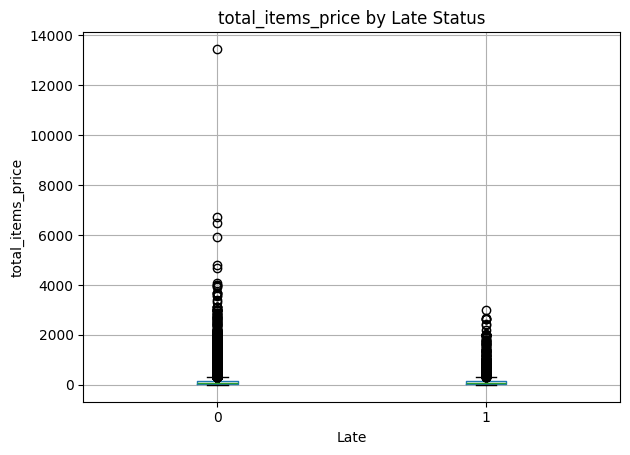

<Figure size 700x500 with 0 Axes>

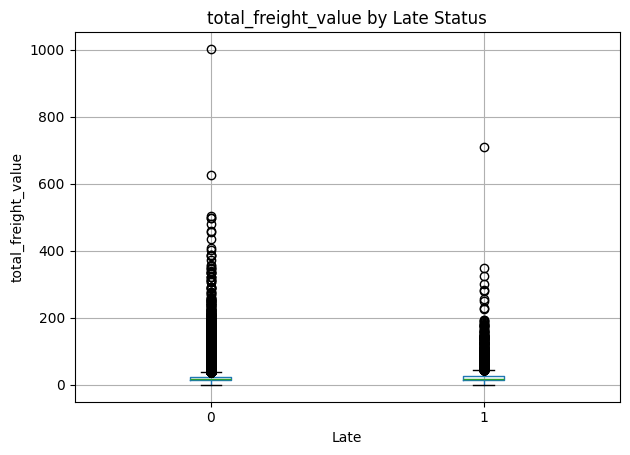

<Figure size 700x500 with 0 Axes>

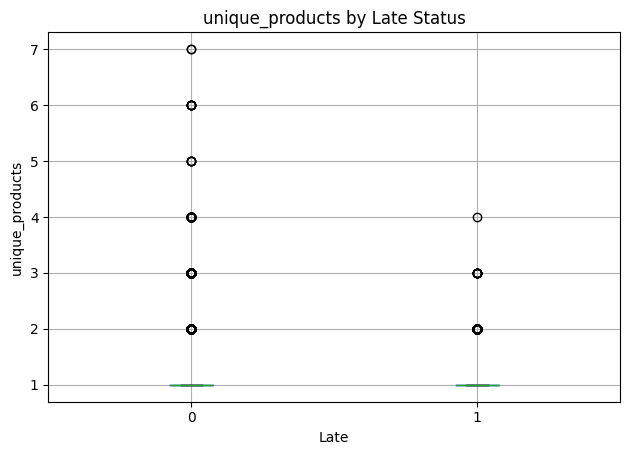

<Figure size 700x500 with 0 Axes>

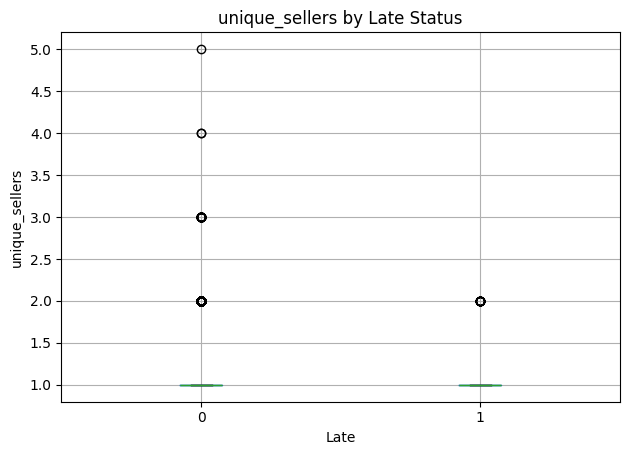

<Figure size 700x500 with 0 Axes>

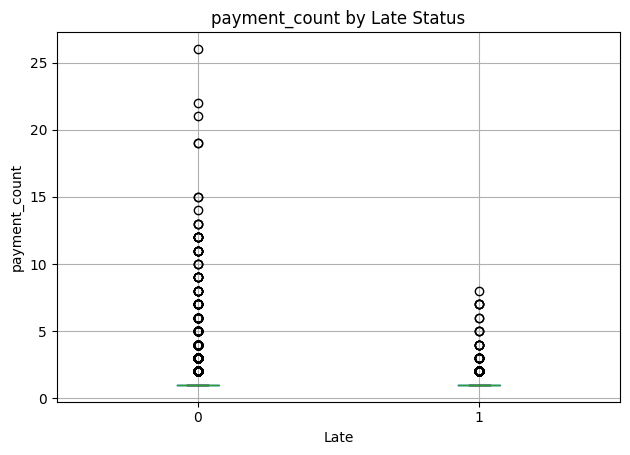

<Figure size 700x500 with 0 Axes>

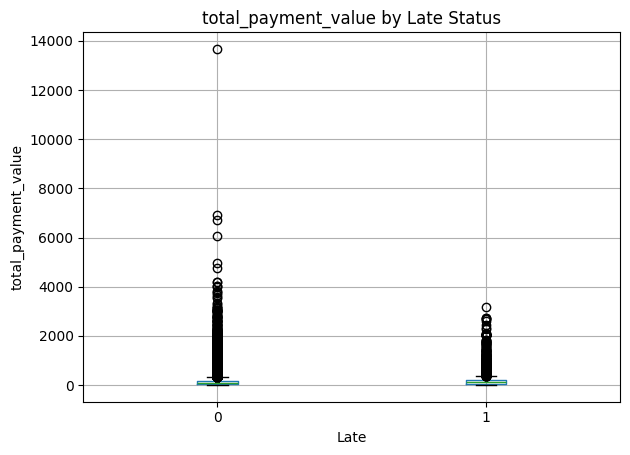

<Figure size 700x500 with 0 Axes>

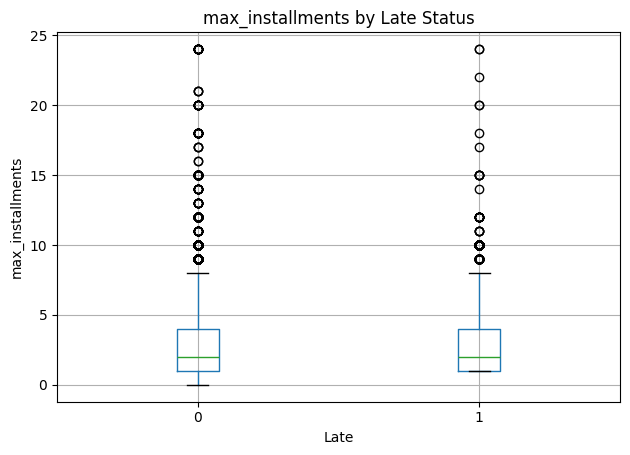

In [15]:
boxplot_features = [
    "item_count",
    "total_items_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "max_installments"
]

for col in boxplot_features:

    plt.figure(figsize=(7, 5))

    train_df.boxplot(
        column=col,
        by="late"
    )

    plt.title(f"{col} by Late Status")
    plt.suptitle("")
    plt.xlabel("Late")
    plt.ylabel(col)

    plt.tight_layout()

    filename = (
        f"../artifacts/eda_plots/"
        f"{col}_by_late_boxplot.png"
    )

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

In [16]:
categorical_eda_columns = [
    "order_status",
    "payment_types",
    "customer_city",
    "customer_state"
]

categorical_summary = pd.DataFrame({
    "unique_values": [
        train_df[col].nunique(dropna=True)
        for col in categorical_eda_columns
    ],
    "missing": [
        train_df[col].isna().sum()
        for col in categorical_eda_columns
    ]
}, index=categorical_eda_columns)

print("=== CATEGORICAL CARDINALITY ===")

display(categorical_summary)

=== CATEGORICAL CARDINALITY ===


,unique_values,missing
order_status,2,0
payment_types,2,1
customer_city,3869,0
customer_state,27,0


In [17]:
for col in categorical_eda_columns:

    print("\n" + "=" * 70)
    print(col)

    print("Unique values:", train_df[col].nunique())

    display(
        train_df[col]
        .value_counts(dropna=False)
        .head(20)
    )


order_status
Unique values: 2


order_status
delivered    77174
canceled         6
Name: count, dtype: int64


payment_types
Unique values: 2


payment_types
1.0    75380
2.0     1799
NaN        1
Name: count, dtype: int64


customer_city
Unique values: 3869


customer_city
sao paulo                11539
rio de janeiro            5373
belo horizonte            2145
brasilia                  1604
curitiba                  1177
campinas                  1104
porto alegre              1100
salvador                   951
guarulhos                  848
sao bernardo do campo      715
niteroi                    655
santo andre                602
osasco                     562
goiania                    528
santos                     522
fortaleza                  513
sao jose dos campos        512
recife                     478
sorocaba                   471
florianopolis              458
Name: count, dtype: int64


customer_state
Unique values: 27


customer_state
SP    31572
RJ    10140
MG     9222
RS     4405
PR     3945
SC     2927
BA     2618
ES     1635
DF     1613
GO     1611
PE     1271
CE     1064
PA      787
MT      734
MA      602
MS      564
PB      404
PI      392
RN      388
AL      331
Name: count, dtype: int64

In [18]:
rare_threshold = 10

print(
    f"=== RARE CATEGORIES "
    f"(fewer than {rare_threshold} observations) ==="
)

for col in categorical_eda_columns:

    counts = train_df[col].value_counts(dropna=False)

    rare = counts[counts < rare_threshold]

    print(f"\n{col}")
    print("Number of rare categories:", len(rare))

    if len(rare) > 0:
        display(rare.head(20))

=== RARE CATEGORIES (fewer than 10 observations) ===

order_status
Number of rare categories: 1


order_status
canceled    6
Name: count, dtype: int64


payment_types
Number of rare categories: 1


payment_types
NaN    1
Name: count, dtype: int64


customer_city
Number of rare categories: 3056


customer_city
buri                    9
paraiso do tocantins    9
parobe                  9
tapejara                9
santa teresa            9
chavantes               9
sao joaquim             9
mangaratiba             9
nova xavantina          9
itapipoca               9
carmo do cajuru         9
italva                  9
salto de pirapora       9
mendes                  9
catu                    9
andradas                9
muzambinho              9
teodoro sampaio         9
ibaiti                  9
palotina                9
Name: count, dtype: int64


customer_state
Number of rare categories: 0


In [19]:
status_late = (
    train_df
    .groupby("order_status")["late"]
    .agg(["count", "mean"])
)

status_late["late_pct"] = (
    status_late["mean"] * 100
).round(2)

status_late = status_late.sort_values(
    "late_pct",
    ascending=False
)

print("=== LATE RATE BY ORDER STATUS ===")

display(status_late)

=== LATE RATE BY ORDER STATUS ===


,count,mean,late_pct
order_status,,,
canceled,6,0.166667,16.67
delivered,77174,0.088177,8.82


In [20]:
# Convert purchase timestamp to datetime

train_df["purchase_dt"] = pd.to_datetime(
    train_df["order_purchase_timestamp"],
    errors="coerce"
)

print(train_df["purchase_dt"].head())
print("\nMissing purchase dates:", train_df["purchase_dt"].isna().sum())

0   2016-09-15 12:16:38
1   2016-10-03 09:44:50
2   2016-10-03 16:56:50
3   2016-10-03 21:01:41
4   2016-10-03 21:13:36
Name: purchase_dt, dtype: datetime64[ns]

Missing purchase dates: 0


In [21]:
train_df["purchase_year"] = (
    train_df["purchase_dt"].dt.year
)

train_df["purchase_month"] = (
    train_df["purchase_dt"].dt.month
)

train_df["purchase_dayofweek"] = (
    train_df["purchase_dt"].dt.dayofweek
)

train_df["purchase_hour"] = (
    train_df["purchase_dt"].dt.hour
)

print(
    train_df[
        [
            "purchase_dt",
            "purchase_year",
            "purchase_month",
            "purchase_dayofweek",
            "purchase_hour"
        ]
    ].head()
)

          purchase_dt  purchase_year  purchase_month  purchase_dayofweek  \
0 2016-09-15 12:16:38           2016               9                   3   
1 2016-10-03 09:44:50           2016              10                   0   
2 2016-10-03 16:56:50           2016              10                   0   
3 2016-10-03 21:01:41           2016              10                   0   
4 2016-10-03 21:13:36           2016              10                   0   

   purchase_hour  
0             12  
1              9  
2             16  
3             21  
4             21  


In [22]:
state_late = (
    train_df
    .groupby("customer_state")["late"]
    .agg(["count", "mean"])
)

state_late["late_pct"] = (
    state_late["mean"] * 100
).round(2)

state_late = state_late.sort_values(
    "late_pct",
    ascending=False
)

print("=== LATE RATE BY CUSTOMER STATE ===")

display(state_late)

=== LATE RATE BY CUSTOMER STATE ===


,count,mean,late_pct
customer_state,,,
AL,331,0.274924,27.49
MA,602,0.207641,20.76
SE,259,0.189189,18.92
CE,1064,0.182331,18.23
PI,392,0.163265,16.33
BA,2618,0.161574,16.16
RR,31,0.161290,16.13
RJ,10140,0.154635,15.46
PA,787,0.144854,14.49


In [23]:
state_late = (
    train_df
    .groupby("customer_state")["late"]
    .agg(["count", "mean"])
)

state_late["late_pct"] = (
    state_late["mean"] * 100
).round(2)

state_late = state_late.sort_values(
    "late_pct",
    ascending=False
)

print("=== LATE RATE BY CUSTOMER STATE ===")

display(state_late)

=== LATE RATE BY CUSTOMER STATE ===


,count,mean,late_pct
customer_state,,,
AL,331,0.274924,27.49
MA,602,0.207641,20.76
SE,259,0.189189,18.92
CE,1064,0.182331,18.23
PI,392,0.163265,16.33
BA,2618,0.161574,16.16
RR,31,0.161290,16.13
RJ,10140,0.154635,15.46
PA,787,0.144854,14.49


In [24]:
city_stats = (
    train_df
    .groupby("customer_city")["late"]
    .agg(["count", "mean"])
)

city_stats["late_pct"] = (
    city_stats["mean"] * 100
).round(2)

city_stats = city_stats.sort_values(
    "count",
    ascending=False
)

print("=== MOST FREQUENT CUSTOMER CITIES ===")

display(city_stats.head(20))

=== MOST FREQUENT CUSTOMER CITIES ===


,count,mean,late_pct
customer_city,,,
sao paulo,11539,0.054857,5.49
rio de janeiro,5373,0.133073,13.31
belo horizonte,2145,0.074592,7.46
brasilia,1604,0.082294,8.23
curitiba,1177,0.056924,5.69
campinas,1104,0.106884,10.69
porto alegre,1100,0.131818,13.18
salvador,951,0.196635,19.66
guarulhos,848,0.056604,5.66


In [25]:
city_stats = (
    train_df
    .groupby("customer_city")["late"]
    .agg(["count", "mean"])
)

city_stats["late_pct"] = (
    city_stats["mean"] * 100
).round(2)

city_stats = city_stats.sort_values(
    "count",
    ascending=False
)

print("=== MOST FREQUENT CUSTOMER CITIES ===")

display(city_stats.head(20))

=== MOST FREQUENT CUSTOMER CITIES ===


,count,mean,late_pct
customer_city,,,
sao paulo,11539,0.054857,5.49
rio de janeiro,5373,0.133073,13.31
belo horizonte,2145,0.074592,7.46
brasilia,1604,0.082294,8.23
curitiba,1177,0.056924,5.69
campinas,1104,0.106884,10.69
porto alegre,1100,0.131818,13.18
salvador,951,0.196635,19.66
guarulhos,848,0.056604,5.66


In [26]:
train_df["purchase_dt"] = pd.to_datetime(
    train_df["order_purchase_timestamp"],
    errors="coerce"
)

train_df["estimated_delivery_dt"] = pd.to_datetime(
    train_df["order_estimated_delivery_date"],
    errors="coerce"
)

print("Purchase date range:")

print(
    train_df["purchase_dt"].min(),
    "→",
    train_df["purchase_dt"].max()
)

print("\nEstimated delivery date range:")

print(
    train_df["estimated_delivery_dt"].min(),
    "→",
    train_df["estimated_delivery_dt"].max()
)

Purchase date range:
2016-09-15 12:16:38 → 2018-05-26 16:54:05

Estimated delivery date range:
2016-10-04 00:00:00 → 2018-08-16 00:00:00


In [27]:
train_df["purchase_dt"] = pd.to_datetime(
    train_df["order_purchase_timestamp"],
    errors="coerce"
)

train_df["estimated_delivery_dt"] = pd.to_datetime(
    train_df["order_estimated_delivery_date"],
    errors="coerce"
)

print("Purchase date range:")

print(
    train_df["purchase_dt"].min(),
    "→",
    train_df["purchase_dt"].max()
)

print("\nEstimated delivery date range:")

print(
    train_df["estimated_delivery_dt"].min(),
    "→",
    train_df["estimated_delivery_dt"].max()
)

Purchase date range:
2016-09-15 12:16:38 → 2018-05-26 16:54:05

Estimated delivery date range:
2016-10-04 00:00:00 → 2018-08-16 00:00:00


In [28]:
train_df["purchase_dt"] = pd.to_datetime(
    train_df["order_purchase_timestamp"],
    errors="coerce"
)

train_df["estimated_delivery_dt"] = pd.to_datetime(
    train_df["order_estimated_delivery_date"],
    errors="coerce"
)

print("Purchase date range:")

print(
    train_df["purchase_dt"].min(),
    "→",
    train_df["purchase_dt"].max()
)

print("\nEstimated delivery date range:")

print(
    train_df["estimated_delivery_dt"].min(),
    "→",
    train_df["estimated_delivery_dt"].max()
)

Purchase date range:
2016-09-15 12:16:38 → 2018-05-26 16:54:05

Estimated delivery date range:
2016-10-04 00:00:00 → 2018-08-16 00:00:00


In [29]:
train_df["purchase_year"] = (
    train_df["purchase_dt"].dt.year
)

train_df["purchase_month"] = (
    train_df["purchase_dt"].dt.month
)

train_df["purchase_dayofweek"] = (
    train_df["purchase_dt"].dt.dayofweek
)

train_df["purchase_hour"] = (
    train_df["purchase_dt"].dt.hour
)

print("Temporal features created.")

Temporal features created.


In [30]:
year_late = (
    train_df
    .groupby("purchase_year")["late"]
    .mean()
    .mul(100)
    .round(2)
)

print("=== LATE RATE BY YEAR ===")

display(year_late)

=== LATE RATE BY YEAR ===


purchase_year
2016     1.47
2017     6.63
2018    11.72
Name: late, dtype: float64

In [31]:
month_late = (
    train_df
    .groupby("purchase_month")["late"]
    .mean()
    .mul(100)
    .round(2)
)

print("=== LATE RATE BY PURCHASE MONTH ===")

display(month_late)

=== LATE RATE BY PURCHASE MONTH ===


purchase_month
1      6.23
2     13.42
3     17.15
4      5.96
5      7.10
6      3.86
7      3.43
8      3.32
9      5.23
10     5.05
11    14.31
12     8.38
Name: late, dtype: float64

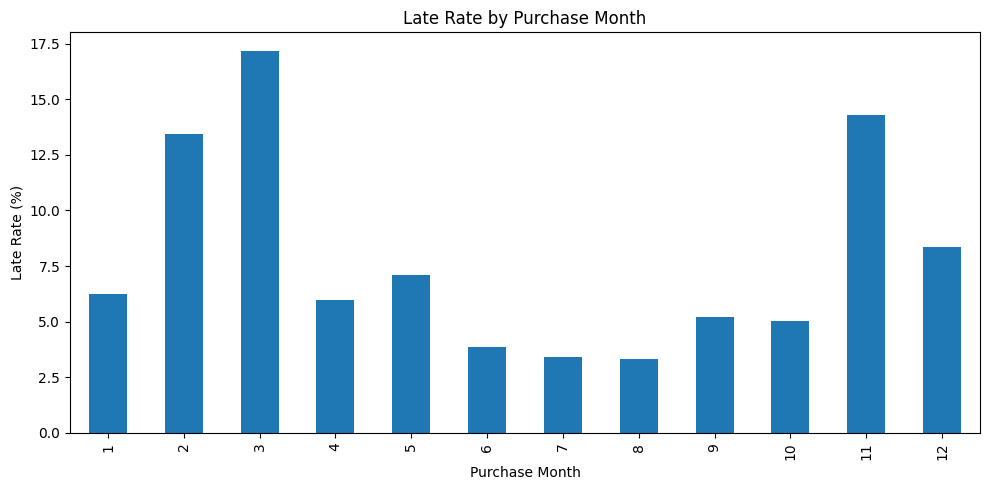

In [32]:
plt.figure(figsize=(10, 5))

month_late.plot(
    kind="bar"
)

plt.title("Late Rate by Purchase Month")
plt.xlabel("Purchase Month")
plt.ylabel("Late Rate (%)")

plt.tight_layout()

plt.savefig(
    "../artifacts/eda_plots/late_rate_by_month.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [33]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

day_late = (
    train_df
    .groupby("purchase_dayofweek")["late"]
    .mean()
    .mul(100)
    .round(2)
)

day_late.index = day_late.index.map(day_names)

print("=== LATE RATE BY DAY OF WEEK ===")

display(day_late)

=== LATE RATE BY DAY OF WEEK ===


purchase_dayofweek
Monday       9.70
Tuesday      9.00
Wednesday    8.57
Thursday     8.12
Friday       9.22
Saturday     8.68
Sunday       8.23
Name: late, dtype: float64

In [34]:
hour_late = (
    train_df
    .groupby("purchase_hour")["late"]
    .mean()
    .mul(100)
    .round(2)
)

print("=== LATE RATE BY PURCHASE HOUR ===")

display(hour_late)

=== LATE RATE BY PURCHASE HOUR ===


purchase_hour
0     9.42
1     8.48
2     7.60
3     4.69
4     6.33
5     7.38
6     7.43
7     8.35
8     8.21
9     8.14
10    8.27
11    8.69
12    9.14
13    8.54
14    8.72
15    8.48
16    8.98
17    8.43
18    8.82
19    9.68
20    9.03
21    9.72
22    9.15
23    9.31
Name: late, dtype: float64

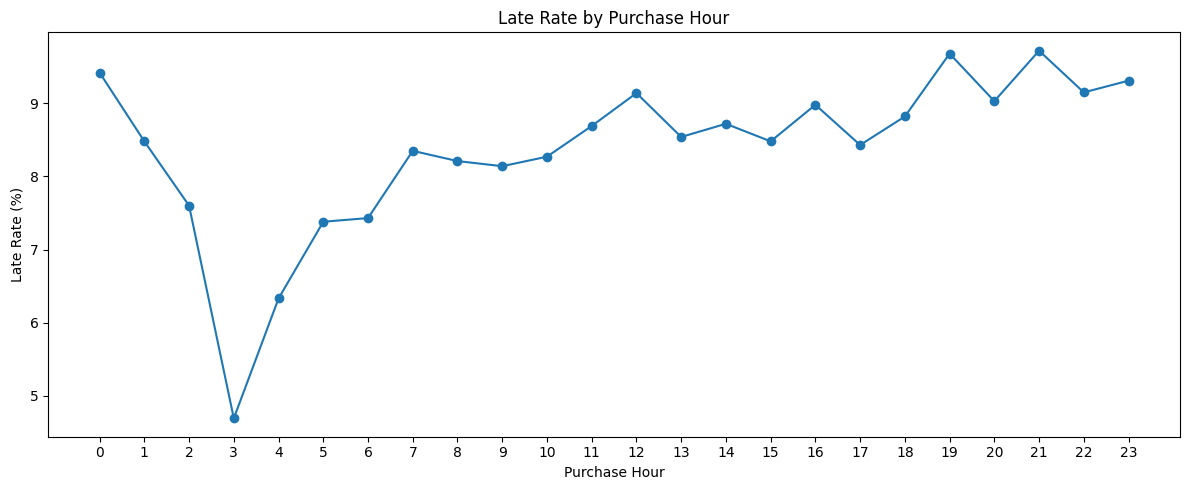

In [35]:
plt.figure(figsize=(12, 5))

hour_late.plot(
    kind="line",
    marker="o"
)

plt.title("Late Rate by Purchase Hour")
plt.xlabel("Purchase Hour")
plt.ylabel("Late Rate (%)")
plt.xticks(range(24))

plt.tight_layout()

plt.savefig(
    "../artifacts/eda_plots/late_rate_by_hour.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [36]:
correlation_features = [
    col for col in numeric_features_for_eda
    if col in train_df.columns
]

correlation_matrix = (
    train_df[correlation_features + ["late"]]
    .corr(numeric_only=True)
)

print("=== CORRELATION WITH TARGET ===")

target_correlations = (
    correlation_matrix["late"]
    .drop("late")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(target_correlations.to_frame("correlation"))

=== CORRELATION WITH TARGET ===


,correlation
review_score,-0.393426
total_freight_value,0.043834
customer_zip_code_prefix,0.042263
unique_sellers,-0.027183
total_payment_value,0.022025
unique_products,-0.021728
total_items_price,0.018699
item_count,-0.017632
max_installments,0.016312
payment_count,-0.005198


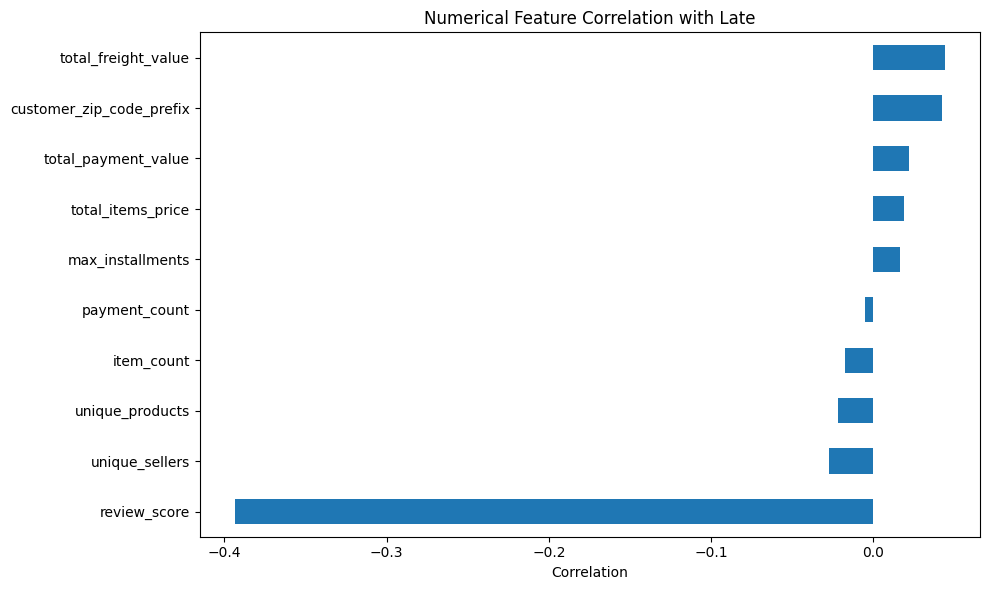

In [37]:
plt.figure(figsize=(10, 6))

target_correlations.sort_values().plot(
    kind="barh"
)

plt.title("Numerical Feature Correlation with Late")
plt.xlabel("Correlation")

plt.tight_layout()

plt.savefig(
    "../artifacts/eda_plots/target_correlations.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [38]:
zip_stats = (
    train_df
    .groupby("customer_zip_code_prefix")["late"]
    .agg(["count", "mean"])
)

zip_stats["late_pct"] = (
    zip_stats["mean"] * 100
).round(2)

print("=== ZIP PREFIX SUMMARY ===")

print(
    "Unique ZIP prefixes:",
    train_df["customer_zip_code_prefix"].nunique()
)

display(
    zip_stats
    .sort_values("count", ascending=False)
    .head(20)
)

=== ZIP PREFIX SUMMARY ===
Unique ZIP prefixes: 14175


,count,mean,late_pct
customer_zip_code_prefix,,,
22790,124,0.153226,15.32
24230,95,0.105263,10.53
24220,93,0.182796,18.28
22793,91,0.351648,35.16
22775,89,0.157303,15.73
29101,83,0.132530,13.25
35162,79,0.075949,7.59
37200,72,0.152778,15.28
36400,69,0.115942,11.59


In [39]:
print("=== POTENTIAL DATA LEAKAGE ===")

leakage_candidates = [
    "late",
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
    "review_score"
]

for col in leakage_candidates:

    if col in train_df.columns:
        print("-", col)

=== POTENTIAL DATA LEAKAGE ===
- late
- order_delivered_customer_date
- order_delivered_carrier_date
- review_score


## Leakage Decisions

The following columns are excluded from modeling because they contain
information that is only available after or around the delivery outcome:

- `late` → target variable.
- `order_delivered_customer_date` → actual delivery outcome.
- `order_delivered_carrier_date` → post-order delivery process information.
- `review_score` → customer review generated after the order experience.

The model should use only information available at prediction time.

In [40]:
print("=== ID COLUMNS ===")

for col in id_cols:

    if col in train_df.columns:

        print(
            f"{col}: "
            f"{train_df[col].nunique():,} unique values "
            f"out of {len(train_df):,} rows"
        )

=== ID COLUMNS ===
order_id: 77,180 unique values out of 77,180 rows
customer_id: 77,180 unique values out of 77,180 rows
customer_unique_id: 74,728 unique values out of 77,180 rows


In [41]:
selected_features = [
    "order_purchase_timestamp",
    "order_estimated_delivery_date",
    "item_count",
    "total_items_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "payment_types",
    "max_installments",
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state"
]

excluded_features = {
    "target": [
        "late"
    ],
    "ids": [
        "order_id",
        "customer_id",
        "customer_unique_id"
    ],
    "post_outcome": [
        "order_delivered_customer_date",
        "order_delivered_carrier_date",
        "review_score"
    ]
}

print("=== FEATURE DECISION ===")

print("\nSelected raw features:")

for feature in selected_features:
    print("-", feature)

print("\nExcluded target columns:")

for feature in excluded_features["target"]:
    print("-", feature)

print("\nExcluded ID columns:")

for feature in excluded_features["ids"]:
    print("-", feature)

print("\nExcluded post-outcome columns:")

for feature in excluded_features["post_outcome"]:
    print("-", feature)

=== FEATURE DECISION ===

Selected raw features:
- order_purchase_timestamp
- order_estimated_delivery_date
- item_count
- total_items_price
- total_freight_value
- unique_products
- unique_sellers
- payment_count
- total_payment_value
- payment_types
- max_installments
- customer_zip_code_prefix
- customer_city
- customer_state

Excluded target columns:
- late

Excluded ID columns:
- order_id
- customer_id
- customer_unique_id

Excluded post-outcome columns:
- order_delivered_customer_date
- order_delivered_carrier_date
- review_score


In [42]:
# ============================================================
# Cell 40 — Feature Decision
# ============================================================

# Create estimated_delivery_days for EDA analysis
train_df["purchase_dt"] = pd.to_datetime(
    train_df["order_purchase_timestamp"],
    errors="coerce"
)

train_df["estimated_delivery_dt"] = pd.to_datetime(
    train_df["order_estimated_delivery_date"],
    errors="coerce"
)

train_df["estimated_delivery_days"] = (
    train_df["estimated_delivery_dt"]
    - train_df["purchase_dt"]
).dt.total_seconds() / (24 * 3600)

print("=== FEATURE DECISION ===")

feature_cols = [
    "estimated_delivery_days",
    "item_count",
    "total_items_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "payment_types",
    "max_installments",
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour"
]

print("Selected features:")
for i, feature in enumerate(feature_cols, 1):
    print(f"{i:02d}. {feature}")

print("\nNumber of selected features:", len(feature_cols))

=== FEATURE DECISION ===
Selected features:
01. estimated_delivery_days
02. item_count
03. total_items_price
04. total_freight_value
05. unique_products
06. unique_sellers
07. payment_count
08. total_payment_value
09. payment_types
10. max_installments
11. customer_zip_code_prefix
12. customer_city
13. customer_state
14. purchase_year
15. purchase_month
16. purchase_dayofweek
17. purchase_hour

Number of selected features: 17


In [43]:
findings = f"""
Notebook 4 — Detailed EDA Findings

Dataset
-------
Training rows: {len(train_df):,}
Training columns: {len(train_df.columns):,}
Unique orders: {train_df["order_id"].nunique():,}

Target
------
On-time orders: {(train_df["late"] == 0).sum():,}
Late orders: {(train_df["late"] == 1).sum():,}
Late rate: {train_df["late"].mean() * 100:.2f}%

Missing Values
--------------
Columns with missing values:
{missing_summary[missing_summary["missing"] > 0].to_string()}

Temporal
--------
Purchase date range:
{train_df["purchase_dt"].min()} -> {train_df["purchase_dt"].max()}

Estimated delivery days:
Mean: {train_df["estimated_delivery_days"].mean():.2f}
Median: {train_df["estimated_delivery_days"].median():.2f}

Leakage
-------
Excluded from modeling:
- late
- order_delivered_customer_date
- order_delivered_carrier_date
- review_score

IDs
---
Excluded:
- order_id
- customer_id
- customer_unique_id

Modeling Direction
------------------
Selected raw features were chosen based on:
- availability at prediction time
- numerical/categorical usefulness
- temporal information
- estimated delivery window
- customer geographic information

The next notebook will perform feature engineering and preprocessing.
"""

print(findings)


Notebook 4 — Detailed EDA Findings

Dataset
-------
Training rows: 77,180
Training columns: 30
Unique orders: 77,180

Target
------
On-time orders: 70,374
Late orders: 6,806
Late rate: 8.82%

Missing Values
--------------
Columns with missing values:
                                dtype  missing  missing_pct  unique
review_score                  float64      561         0.73      11
order_approved_at              object       14         0.02   71511
order_delivered_carrier_date   object        1         0.00   69164
total_payment_value           float64        1         0.00   23139
payment_types                 float64        1         0.00       2
payment_count                 float64        1         0.00      19
max_installments              float64        1         0.00      23

Temporal
--------
Purchase date range:
2016-09-15 12:16:38 -> 2018-05-26 16:54:05

Estimated delivery days:
Mean: 24.33
Median: 23.50

Leakage
-------
Excluded from modeling:
- late
- order_delivered_cus

In [44]:
findings_path = "../artifacts/eda_findings.txt"

with open(
    findings_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(findings)

print("EDA findings saved successfully!")
print("Path:", findings_path)

EDA findings saved successfully!
Path: ../artifacts/eda_findings.txt


In [45]:
features_path = "../artifacts/eda_selected_features.txt"

with open(
    features_path,
    "w",
    encoding="utf-8"
) as f:

    f.write("Selected features:\n")

    for feature in selected_features:
        f.write(f"{feature}\n")

    f.write("\nExcluded target:\n")

    for feature in excluded_features["target"]:
        f.write(f"{feature}\n")

    f.write("\nExcluded IDs:\n")

    for feature in excluded_features["ids"]:
        f.write(f"{feature}\n")

    f.write("\nExcluded post-outcome columns:\n")

    for feature in excluded_features["post_outcome"]:
        f.write(f"{feature}\n")

print("Feature decision saved successfully!")
print("Path:", features_path)

Feature decision saved successfully!
Path: ../artifacts/eda_selected_features.txt


In [46]:
print("=" * 70)
print("NOTEBOOK 4 COMPLETED")
print("=" * 70)

print("\nTraining dataset:", train_df.shape)

print(
    "\nLate rate:",
    round(train_df["late"].mean() * 100, 2),
    "%"
)

print(
    "\nSelected raw features:",
    len(selected_features)
)

print("\nArtifacts created:")

print("- ../artifacts/eda_plots/")
print("- ../artifacts/eda_findings.txt")
print("- ../artifacts/eda_selected_features.txt")



NOTEBOOK 4 COMPLETED

Training dataset: (77180, 30)

Late rate: 8.82 %

Selected raw features: 14

Artifacts created:
- ../artifacts/eda_plots/
- ../artifacts/eda_findings.txt
- ../artifacts/eda_selected_features.txt
